# transfer Learning with ensorFlor Part 3: Scaling up(Food Vision Mini)

We've seen the power of transfer learning feature ectraction and fine-tuning, now it's time to scale up to all of the classes in Food101 (101 total classses of food).

Our goal is to beat the original Food101 paper with 10% of the training (leveraging the power of deep learning).

[Food 101 paper](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf)

Our baseline to beat is 50.76% accuracy across 101 classes.

In [1]:
# ========================
# 🚀 CONFIGURAÇÃO RÁPIDA
# ========================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"TensorFlow {tf.__version__} - Geekom A9 Max")
devices = tf.config.list_physical_devices()
for d in devices:
    print(f"✅ {d.device_type.upper()}: {d.name}")

# Configurar gráficos
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 6]

print("✅ Notebook configurado!")


TensorFlow 2.15.0 - Geekom A9 Max
✅ CPU: /physical_device:CPU:0
✅ Notebook configurado!


In [2]:
# 📈 MONITOR DE PERFORMANCE
import time
from IPython.display import clear_output

class PerformanceMonitor:
    def __init__(self):
        self.start_time = None
        self.batch_times = []
    
    def start_epoch(self):
        self.start_time = time.time()
        self.batch_times = []
    
    def record_batch(self, batch_num, total_batches):
        elapsed = time.time() - self.start_time
        self.batch_times.append(elapsed)
        
        if batch_num % 10 == 0:
            avg_time = np.mean(self.batch_times[-10:]) if len(self.batch_times) >= 10 else elapsed
            eta = avg_time * (total_batches - batch_num)
            
            clear_output(wait=True)
            print(f"Batch {batch_num}/{total_batches}")
            print(f"Tempo/batch: {avg_time:.3f}s")
            print(f"ETA: {eta/60:.1f} minutos")
            print("-" * 40)

# Usar:
monitor = PerformanceMonitor()

In [3]:
import os
import tensorflow as tf

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1" 

tf.config.threading.set_intra_op_parallelism_threads(24)
tf.config.threading.set_inter_op_parallelism_threads(4)

tf.config.set_visible_devices([], 'GPU')

print("CPUs:", os.cpu_count())


CPUs: 24


### Creating helper functions

In previous notebooks, we've created a series of helper functions to different tasks.

In [4]:
# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir

## 101 Food Classes: working with less data

Our goal is to beat the original Food101 dataset but has been preprocessed using the image_data_modification.ipynb

In [5]:
# import zipfile
# import urllib.request

# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip"
# zip_path = "101_food_classes_10_percent.zip"
# urllib.request.urlretrieve(url, zip_path)

# # # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()

train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

In [6]:
# How many images/classes are there?
# check out how many images and subdirectorys are in our dataset
from helper_functions import walk_through_dir
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent\test'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\apple_pie'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\baby_back_ribs'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\baklava'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beef_carpaccio'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beef_tartare'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beet_salad'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beignets'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\bibimbap'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\bread_pudding'.
There are 0 directories and 250 images in '10

In [7]:
# Setup data inputs

from random import shuffle

import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
                                                                                train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                shuffle=False) # don't shuffle test data for prediction analysis

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


## Train a big dog model with transfer learning on 10% of 101 food classes

Here are the steps we're going to take:
* Create a ModelCheckpoint callback
* Create a data augmentation layer to build data augmentation right into the model
* Build a headless (no top layers) Functional EfficientNetB0 backboned-model (we'll create our own output layer)
* Compile our model
* Feature extract for 5 full passes (5 epochs on the train dataset and validate on 15% of the test data, to save epoch time)

In [8]:
# Create a ModelCheckpoint callback
checkpoint_path = "101_food_classes_10_percent_data_model_checkpoint"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only=True)


In [9]:
# Create data augmentation layer to build data augmentation right into the Model
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.models import Sequential

# Setup data augmentation
data_augmentation = Sequential([
    preprocessing.RandomFlip("horizontal"),
    preprocessing.RandomRotation(0.2),
    preprocessing.RandomHeight(0.2),
    preprocessing.RandomZoom(0.2),
    preprocessing.RandomZoom(0.2),
    # preprocessing.Rescaling(1/255.) # rescale inputs of images to between 0 & 1, required for models like ResNet50
], name="data_augmentation")



In [10]:
# Setup the base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name='input_layer')
x = data_augmentation(inputs) # augment images (only happens during training phase)
x = base_model(x, training=False) # extract features from base model
x = layers.GlobalAveragePooling2D(name='global_avg_pool_layer')(x) # extract features from base model
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation='softmax', name='output_layer')(x) # output layer
model = tf.keras.Model(inputs, outputs)

In [11]:
# get a summary of model we've created
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, None, 224, 3)      0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, None, None, 1280   4049571   
 )                           )                                   
                                                                 
 global_avg_pool_layer (Glo  (None, 1280)              0         
 balAveragePooling2D)                                            
                                                                 
 output_layer (Dense)        (None, 101)               129381    
                                                             

In [12]:
# Compile
model.compile(loss="categorical_crossentropy", 
              optimizer="adam", 
              metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent, 
                                         epochs=5, # fit for 5 epochs to keep experiments quick
                                         validation_data=test_data, # use the test data for validation
                                         validation_steps=int(0.15 * len(test_data)), # 15% of the test data is used for validation
                                         callbacks = [checkpoint_callback]) # save the best model during training


Epoch 1/5


237/237 [==============================] - 63s 252ms/step - loss: 3.4887 - accuracy: 0.2444 - val_loss: 2.5707 - val_accuracy: 0.4476
Epoch 2/5
237/237 [==============================] - 58s 245ms/step - loss: 2.3454 - accuracy: 0.4704 - val_loss: 2.0570 - val_accuracy: 0.5103
Epoch 3/5
237/237 [==============================] - 58s 245ms/step - loss: 1.9743 - accuracy: 0.5333 - val_loss: 1.9360 - val_accuracy: 0.5146
Epoch 4/5
237/237 [==============================] - 59s 248ms/step - loss: 1.7643 - accuracy: 0.5700 - val_loss: 1.8167 - val_accuracy: 0.5344
Epoch 5/5
237/237 [==============================] - 59s 249ms/step - loss: 1.6012 - accuracy: 0.6094 - val_loss: 1.7366 - val_accuracy: 0.5583


In [13]:
# Evaluate on the whole test dataset
feature_extraction_results = model.evaluate(test_data)
print(feature_extraction_results)

790/790 [==============================] - 127s 161ms/step - loss: 1.6167 - accuracy: 0.5779
[1.6167116165161133, 0.5778613686561584]


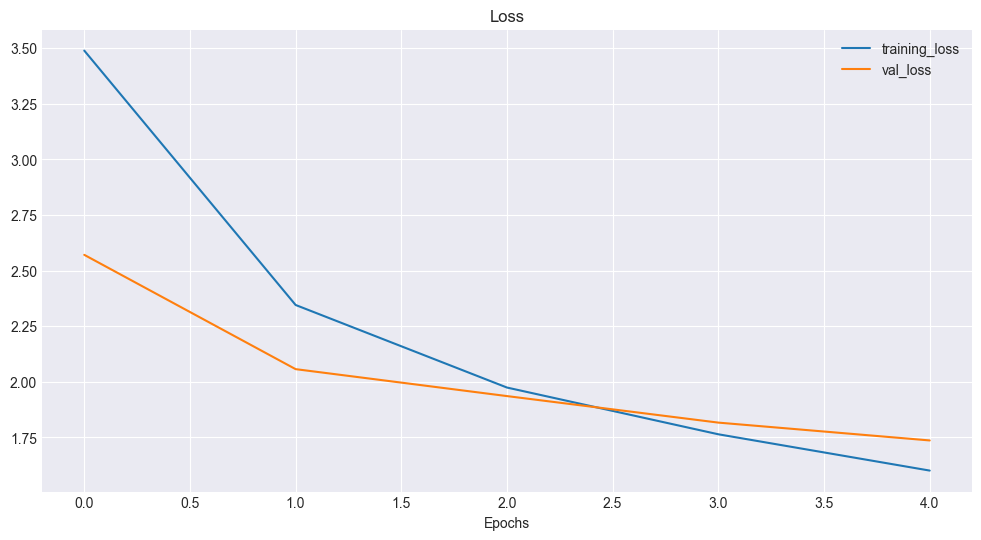

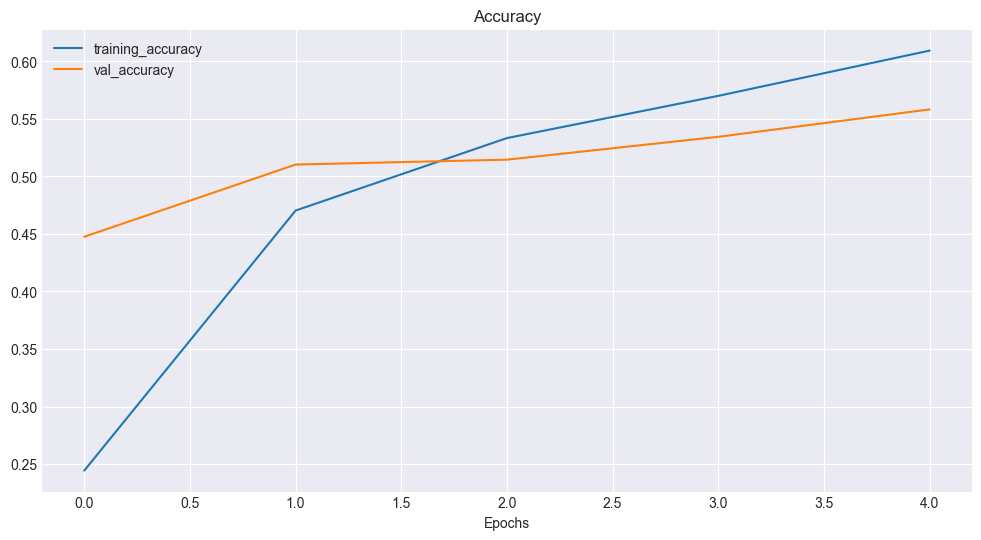

In [14]:
plot_loss_curves(history_all_classes_10_percent)

>> **Question:** What do these curves suggest? Hint: ideally, the two curves should be very similar to each other, if not it may suggest that our model is overfitting (performing too well on the training data and not generalizin to unseen data).

## Fine-tunning

In [15]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

#Refreeze every layer except the last 5 layers
for layer in base_model.layers[:-5]:
    layer.trainable = False

In [16]:
# recompile model with lower learning rate (it's tipically best practice to lower the learing rate when fine-tuning)
model.compile(loss='categorical_crossentropy', 
              optimizer=tf.keras.optimizers.Adam(lr=0.0001), # learning rate lower by 10x 
              metrics=['accuracy'])

In [17]:
# What layers in the model are trainable?
for layer in model.layers:
    print(layer.name, layer.trainable)  

input_layer True
data_augmentation True
efficientnetb0 True
global_avg_pool_layer True
output_layer True


In [18]:
# Check wich layers are trainable in our base model
for layer_number, layer in enumerate(model.layers[2].layers):
    print(layer_number, layer.name, layer.trainable)

0 input_1 False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze False
39

In [19]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs (feature extraction), this is the total number of epochs we're after (5 + 5 = 10)

# Fine-tuning our model
history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)),
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1])

Epoch 5/10
237/237 [==============================] - 69s 277ms/step - loss: 1.6193 - accuracy: 0.5678 - val_loss: 1.7922 - val_accuracy: 0.5426
Epoch 6/10
237/237 [==============================] - 65s 273ms/step - loss: 1.2128 - accuracy: 0.6668 - val_loss: 1.8230 - val_accuracy: 0.5350
Epoch 7/10
237/237 [==============================] - 64s 269ms/step - loss: 1.0090 - accuracy: 0.7175 - val_loss: 1.7859 - val_accuracy: 0.5501
Epoch 8/10
237/237 [==============================] - 65s 273ms/step - loss: 0.7914 - accuracy: 0.7768 - val_loss: 1.7223 - val_accuracy: 0.5683
Epoch 9/10
237/237 [==============================] - 64s 270ms/step - loss: 0.6670 - accuracy: 0.8074 - val_loss: 1.9315 - val_accuracy: 0.5485
Epoch 10/10
237/237 [==============================] - 63s 264ms/step - loss: 0.5507 - accuracy: 0.8409 - val_loss: 2.0878 - val_accuracy: 0.5289


In [20]:
# Evaluate on the whole test dataset
all_classes_10_percent_fine_tune_results = model.evaluate(test_data)
all_classes_10_percent_fine_tune_results

790/790 [==============================] - 122s 154ms/step - loss: 1.8873 - accuracy: 0.5663


[1.8872894048690796, 0.5662970542907715]

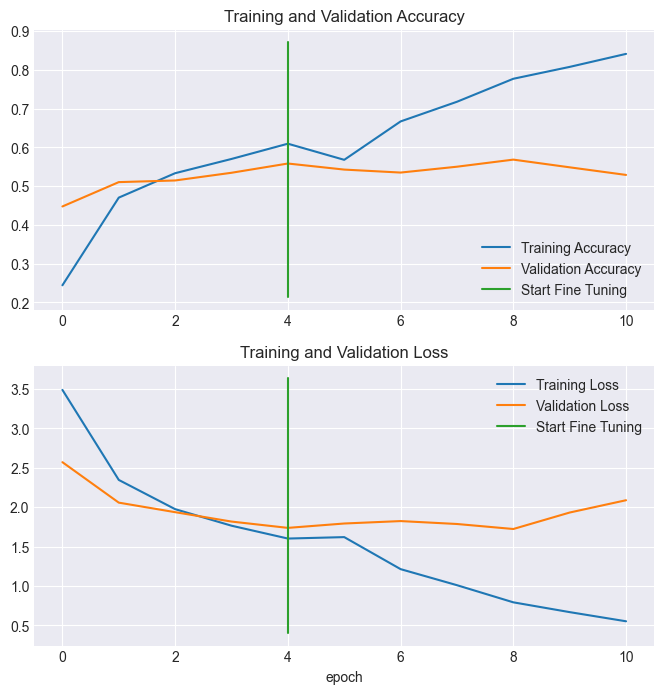

In [21]:
# Compare the histories of feature extraction model with fine-tuning model
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

## Saving and loading our model

To use our model in an external application, we'll need to save it and export it somewhere.

In [22]:
# Save our fine-tuning model
model.save("C:\\Project_1\\Tensorflow-1\\Files&notebooks\\06_Transfer_learning_scaling_up\\101_food_classes_10_percent_saved_big_dog_model")


INFO:tensorflow:Assets written to: C:\Project_1\Tensorflow-1\Files&notebooks\06_Transfer_learning_scaling_up\101_food_classes_10_percent_saved_big_dog_model\assets


INFO:tensorflow:Assets written to: C:\Project_1\Tensorflow-1\Files&notebooks\06_Transfer_learning_scaling_up\101_food_classes_10_percent_saved_big_dog_model\assets


In [23]:
# Load an evaluate saved model
loaded_model = tf.keras.models.load_model('C:\\Project_1\\Tensorflow-1\\Files&notebooks\\06_Transfer_learning_scaling_up\\101_food_classes_10_percent_saved_big_dog_model')

In [24]:
# Evaluate loaded model and compare performance to pre-saved model
loaded_model_results = loaded_model.evaluate(test_data)
loaded_model_results

790/790 [==============================] - 129s 161ms/step - loss: 1.8873 - accuracy: 0.5663


[1.8872894048690796, 0.5662970542907715]

In [25]:
# The resultes of our model above should be very similar to our model below
all_classes_10_percent_fine_tune_results

[1.8872894048690796, 0.5662970542907715]

## Evaluating the performance of the big dog model acorss all different classes

Let's make some predictions, visualize them and then later find out wich predictions were the "most" wrong.

In [26]:
import zipfile
import urllib.request
import tensorflow as tf

# Download pretrained model (one that was prepared earlier, so all predsictions are similar)
# Baixar o arquivo ZIP
url = "https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip"
zip_path = "101_food_classes_10_percent.zip"
urllib.request.urlretrieve(url, zip_path)

# # Descompactar o arquivo ZIP
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall()


In [27]:
# Load in saved models
model = tf.keras.models.load_model("C:\\Project_1\\06_101_food_class_10_percent_saved_big_dog_model")

In [30]:
# evaluate loaded model (the one we just dowloaded on test data)
results_downloaded_model = model.evaluate(test_data)
print("Loss of downloaded model: ", results_downloaded_model[0])

790/790 [==============================] - 132s 166ms/step - loss: 1.8027 - accuracy: 0.6078
Loss of downloaded model:  1.8027209043502808


In [31]:
## Making predictions with our trained model
preds_probs = model.predict(test_data, verbose=1) # set verbosity to see how long is left

790/790 [==============================] - 133s 167ms/step


In [32]:
len(test_data)

790

In [ ]:
790*32 # 

25280

In [34]:
# How many predictions are there?
len(preds_probs)

25250

In [ ]:
# Whats the shape of our predictions?
preds_probs.shape # (images,shape)

(25250, 101)

In [37]:
# let's see what the first 10 predictions look like
preds_probs[:10]


array([[5.95418625e-02, 3.57423733e-06, 4.13773581e-02, ...,
        1.41387546e-09, 8.35309547e-05, 3.08973808e-03],
       [9.64016676e-01, 1.37531675e-09, 8.47801974e-04, ...,
        5.42870403e-05, 7.83623513e-12, 9.84660242e-10],
       [9.59258616e-01, 3.25336114e-05, 1.48669595e-03, ...,
        7.18917477e-07, 5.43963722e-07, 4.02757323e-05],
       ...,
       [4.73133028e-01, 1.29310834e-07, 1.48056541e-03, ...,
        5.97499602e-04, 6.69690198e-05, 2.34692707e-05],
       [4.45717759e-02, 4.72652545e-07, 1.22584715e-01, ...,
        6.34988646e-06, 7.53180802e-06, 3.67786223e-03],
       [7.24389851e-01, 1.92496685e-09, 5.23112540e-05, ...,
        1.22914289e-03, 1.57928104e-09, 9.63958664e-05]], dtype=float32)

In [ ]:
# What does the first prediction probability look like?
preds_probs[0], len(preds_probs[0]), sum(preds_probs[0]) # ~ 1

(array([5.9541862e-02, 3.5742373e-06, 4.1377358e-02, 1.0660632e-09,
        8.1615035e-09, 8.6640126e-09, 8.0927788e-07, 8.5652709e-07,
        1.9859179e-05, 8.0978123e-07, 3.1727851e-09, 9.8675207e-07,
        2.8532289e-04, 7.8049467e-10, 7.4230268e-04, 3.8916329e-05,
        6.4740839e-06, 2.4977439e-06, 3.7891336e-05, 2.0678279e-07,
        1.5538519e-05, 8.1507454e-07, 2.6230955e-06, 2.0010869e-07,
        8.3827655e-07, 5.4216530e-06, 3.7391087e-06, 1.3150602e-08,
        2.7761601e-03, 2.8051878e-05, 6.8562650e-10, 2.5574944e-05,
        1.6689001e-04, 7.6407264e-10, 4.0453169e-04, 1.3150729e-08,
        1.7957352e-06, 1.4448224e-06, 2.3063021e-02, 8.2467142e-07,
        8.5365980e-07, 1.7138653e-06, 7.0525939e-06, 1.8402197e-08,
        2.8553472e-07, 7.9483725e-06, 2.0681803e-06, 1.8525216e-07,
        3.3619763e-08, 3.1522632e-04, 1.0411038e-05, 8.5449227e-07,
        8.4741831e-01, 1.0555541e-05, 4.4094858e-07, 3.7404487e-05,
        3.5306286e-05, 3.2489090e-05, 6.7314591e

Our model outputs a prediction probability array (with N number of variables, where N is the number of classes) for each sample passed to the predict method.

In [44]:
# We get one prediction probability per class ( in our case there's 101 prediction probabilities)
print(f"Number of prediction probabilities for sample 0: {len(preds_probs[0])}")
print(f"First prediction probability for sample 0: {preds_probs[0][0]}")
print(f"The class with the highest prediction probability by the model for sample 0: {np.argmax(preds_probs[0])}")

Number of prediction probabilities for sample 0: 101
First prediction probability for sample 0: 0.059541862457990646
The class with the highest prediction probability by the model for sample 0: 52


In [45]:
test_data.class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [47]:
test_data.class_names[52]

'gyoza'

In [49]:
# Get the pred class of each label
preds_classes = np.argmax(preds_probs, axis=1)

# how many pred classes do we have?
len(preds_classes)

25250

Now we've got a predictions array of all of our model's predictions, to evaluate them, we need to compare them to the original test data

In [52]:
# To get our test labels we need to unravel our test_data BatchDataset
from numpy import test


y_labels = []
for images, labels in test_data. unbatch():
    y_labels.append(labels.numpy().argmax()) # currently test labels look like: [0, 0, 0, 1, ...., 0, 0] we wante the index value where the 1 occurs
y_labels[:10] # look at the first 10 labels

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
# How many y_labels do we have?
len(y_labels)

25250

In [54]:
test_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>

## Evaluating our model's predictions
One way to check that our model's predictions array is in the same order as our test labels array is to find the accuracy score.

In [55]:
results_downloaded_model

[1.8027209043502808, 0.6077623963356018]

In [97]:
 # let's try scikit-learn's accuracy score function and see what it comes up with
import sklearn
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_true=y_labels,
                                  y_pred=preds_classes)

sklearn_accuracy

0.6077623762376237

In [98]:
# Does this metric come close to our model's evaluate results
import numpy as np
np.isclose(results_downloaded_model[1], sklearn_accuracy)

True

## let's get visual: making a confusion matrix

In [103]:
from helper_functions import make_confusion_matrix

In [89]:
# get a list of class names
class_names = test_data.class_names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [104]:
make_confusion_matrix(  y_true=y_labels,
                        y_pred=preds_classes,
                        classes=class_names,
                        figsize=(100, 100),
                        text_size=20)